# Chapter 4 — Mathematical Curiosity and Exploration

> **Prerequisites:** ch001–ch003
>
> **You will learn:**
> - How mathematicians actually discover things: experiment first, prove second
> - The computational exploration loop: conjecture → test → refine → generalize
> - How to turn a vague observation into a precise, testable claim
> - Why "I wonder what happens if..." is a mathematical method, not a distraction
>
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Mathematics as taught in school presents finished results: theorems, proofs, formulas. This creates a false picture of how mathematics is actually done. Real mathematical work begins with *exploration* — playing with examples, noticing patterns, asking whether a pattern always holds, and only then attempting a proof.

Computational tools make this process faster and more accessible. You can test a conjecture on 10,000 cases in seconds. That does not replace a proof, but it tells you whether pursuing one is worth the effort.

**The exploration loop:**
1. Observe something in a specific case
2. Ask: does this hold in other cases?
3. Compute: test it on many cases
4. Refine: narrow down *when* it holds
5. Conjecture: state the pattern precisely
6. Prove (or find a counterexample)

This chapter focuses on steps 1–5. Step 6 comes in ch015–ch016.

**Common misconception:** Exploration without proof is not mathematics.

Exploration *is* mathematics — it is the generative phase. A proof is the verification phase. Both are necessary. Skipping exploration leads to proofs of things nobody cares about. Skipping proof leads to false conjectures treated as facts.

## 2. Intuition & Mental Models

**Physical analogy:** Think of exploration as surveying terrain before building a road. You walk the landscape, note where the hills are, where the ground is soft, where the natural paths form. Only after that survey do you commit to a specific route and invest in construction. Mathematical exploration surveys the landscape of a problem before committing to a proof strategy.

**Computational analogy:** Think of fuzzing in software testing. A fuzzer generates thousands of random inputs and looks for crashes. It does not prove the program is correct — but it builds confidence and finds edge cases efficiently. Mathematical exploration is mathematical fuzzing: generate many cases, look for failures, build a map of where things break.

Recall from ch003 *(Abstraction and Modeling)*: we identified structure by testing data against candidate models. That was exploration. The R² score told us where to look; it did not constitute a proof.

## 3. Visualization

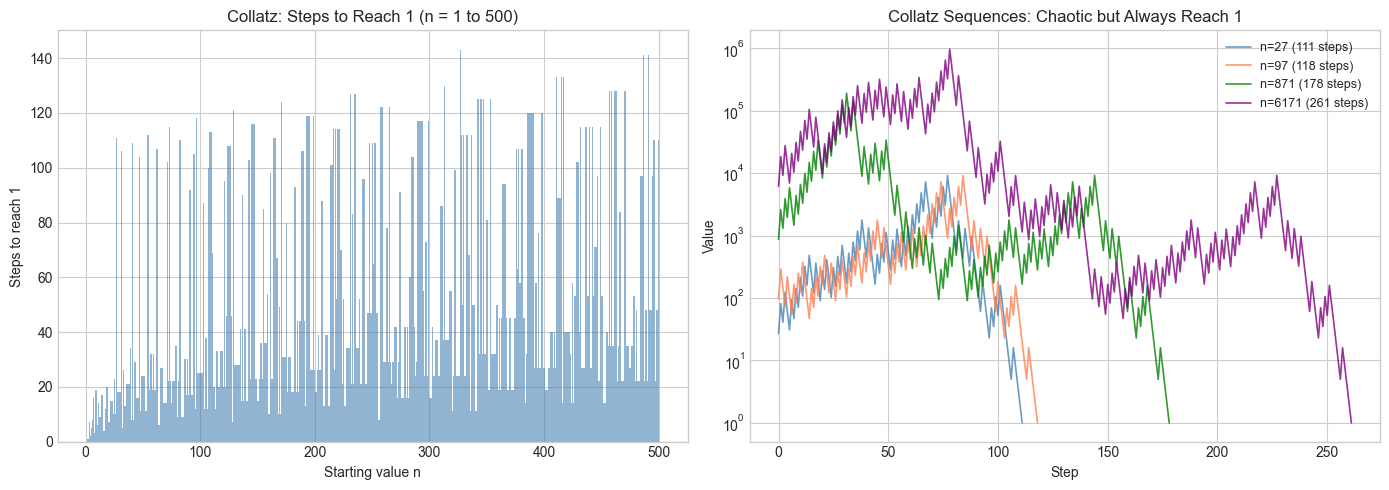

Longest sequence for n ≤ 500: starts at n=327, length=143
No counterexample has ever been found. But no proof exists either.
This is what open mathematical exploration looks like.


In [1]:
# --- Visualization: The Collatz conjecture — a famous unsolved exploration ---
# Rule: if n is even, divide by 2; if odd, multiply by 3 and add 1.
# Conjecture: every positive integer eventually reaches 1.
# Status: unproven after 85 years. Verified computationally for n up to ~10^20.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def collatz_sequence(n):
    """Generate the full Collatz sequence starting from n."""
    seq = [n]
    while n != 1:
        n = n // 2 if n % 2 == 0 else 3 * n + 1
        seq.append(n)
    return seq

def collatz_length(n):
    """Number of steps to reach 1 from n."""
    return len(collatz_sequence(n)) - 1

N_MAX = 500
ns = np.arange(1, N_MAX + 1)
lengths = np.array([collatz_length(n) for n in ns])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: steps to reach 1
axes[0].bar(ns, lengths, width=1.0, alpha=0.6, color='steelblue')
axes[0].set_xlabel('Starting value n')
axes[0].set_ylabel('Steps to reach 1')
axes[0].set_title('Collatz: Steps to Reach 1 (n = 1 to 500)')

# Right: sequences for several starting points
STARTS = [27, 97, 871, 6171]
colors = ['steelblue', 'coral', 'green', 'purple']
for start, color in zip(STARTS, colors):
    seq = collatz_sequence(start)
    axes[1].plot(seq, alpha=0.8, linewidth=1.2, label=f'n={start} ({len(seq)-1} steps)', color=color)
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Value')
axes[1].set_title('Collatz Sequences: Chaotic but Always Reach 1')
axes[1].legend(fontsize=9)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Longest sequence for n ≤ {N_MAX}: starts at n={ns[np.argmax(lengths)]}, length={lengths.max()}")
print("No counterexample has ever been found. But no proof exists either.")
print("This is what open mathematical exploration looks like.")

## 4. Mathematical Formulation

A **conjecture** is a precisely stated claim that has not yet been proved or disproved. The precision requirement is non-negotiable: a vague pattern observation is not a conjecture.

**Structure of a well-formed conjecture:**

> For all [objects of type X] satisfying [conditions C], the property [P] holds.

Examples:
- *Vague:* "Even numbers seem to be sums of two primes."
- *Conjecture (Goldbach, 1742):* For every even integer $n > 2$, there exist primes $p$ and $q$ such that $n = p + q$.

The computational exploration loop tests a conjecture by:
1. Formalizing it as a predicate $P(n)$
2. Evaluating $P(n)$ for $n \in \{n_1, n_2, \ldots, n_k\}$
3. Reporting: all passed, or counterexample found at $n = n^*$

If all pass: the conjecture is *consistent with the evidence* — not proved.
If a counterexample is found: the conjecture is *false* — definitively.

This asymmetry (easy to disprove, hard to prove) is fundamental.

In [2]:
# --- Implementation: Conjecture tester ---
import numpy as np

def test_conjecture(predicate, domain_generator, n_tests=10000, name='unnamed'):
    """
    Test a mathematical conjecture computationally.
    
    Args:
        predicate:        callable(n) -> bool, the claim to test
        domain_generator: callable() -> one element of the domain
        n_tests:          number of cases to test
        name:             description of the conjecture
    Returns:
        dict with results
    """
    passed = 0
    counterexample = None
    for _ in range(n_tests):
        val = domain_generator()
        if not predicate(val):
            counterexample = val
            break
        passed += 1
    
    result = 'COUNTEREXAMPLE FOUND' if counterexample else f'consistent ({passed} cases)'
    print(f"Conjecture: {name}")
    print(f"  Result: {result}")
    if counterexample is not None:
        print(f"  Counterexample: {counterexample}")
    print()
    return {'passed': passed, 'counterexample': counterexample}

# --- Helper: primality test ---
def is_prime(n):
    if n < 2: return False
    if n == 2: return True
    if n % 2 == 0: return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0: return False
    return True

np.random.seed(42)

# Conjecture 1: Goldbach (every even n > 2 is sum of two primes)
def goldbach(n):
    for p in range(2, n):
        if is_prime(p) and is_prime(n - p):
            return True
    return False

test_conjecture(
    predicate=goldbach,
    domain_generator=lambda: np.random.randint(2, 500) * 2 + 2,  # even > 2
    n_tests=5000,
    name="Every even n > 2 is the sum of two primes (Goldbach)"
)

# Conjecture 2: n² + n + 41 is always prime (Euler's formula — FALSE)
def euler_prime_formula(n):
    return is_prime(n * n + n + 41)

test_conjecture(
    predicate=euler_prime_formula,
    domain_generator=lambda: np.random.randint(0, 100),
    n_tests=200,
    name="n² + n + 41 is always prime (Euler's formula — expect failure)"
)

# Conjecture 3: (your own) — modify this
# Claim: the sum of first n cubes equals (n(n+1)/2)²
def sum_of_cubes(n):
    actual = sum(k**3 for k in range(1, n + 1))
    formula = (n * (n + 1) // 2) ** 2
    return actual == formula

test_conjecture(
    predicate=sum_of_cubes,
    domain_generator=lambda: np.random.randint(1, 200),
    n_tests=500,
    name="Sum of first n cubes = (n(n+1)/2)²"
)

Conjecture: Every even n > 2 is the sum of two primes (Goldbach)
  Result: consistent (5000 cases)

Conjecture: n² + n + 41 is always prime (Euler's formula — expect failure)
  Result: COUNTEREXAMPLE FOUND
  Counterexample: 49

Conjecture: Sum of first n cubes = (n(n+1)/2)²
  Result: consistent (500 cases)



{'passed': 500, 'counterexample': None}

## 5. Python Implementation

In [3]:
# --- Implementation: Exploration journal ---
# A structured record of mathematical exploration.
# Each entry: observation, conjecture, computational test, status.

class ExplorationJournal:
    """
    Records mathematical explorations in the conjecture → test → result cycle.
    """
    def __init__(self):
        self.entries = []
    
    def explore(self, observation, conjecture_fn, domain_gen,
                n_tests=1000, conjecture_text=''):
        """
        Record an exploration step.
        
        Args:
            observation:     what triggered this investigation (string)
            conjecture_fn:   predicate to test
            domain_gen:      input generator
            n_tests:         number of test cases
            conjecture_text: precise statement of the conjecture
        """
        passed = 0
        counterexample = None
        for _ in range(n_tests):
            val = domain_gen()
            if not conjecture_fn(val):
                counterexample = val
                break
            passed += 1
        
        entry = {
            'observation': observation,
            'conjecture': conjecture_text,
            'tests': n_tests,
            'passed': passed,
            'counterexample': counterexample,
            'status': 'REFUTED' if counterexample else 'CONSISTENT',
        }
        self.entries.append(entry)
        return entry
    
    def report(self):
        print("=" * 60)
        print("EXPLORATION JOURNAL")
        print("=" * 60)
        for i, e in enumerate(self.entries, 1):
            print(f"\n[{i}] Observation: {e['observation']}")
            print(f"    Conjecture:  {e['conjecture']}")
            print(f"    Tested:      {e['tests']} cases")
            print(f"    Status:      {e['status']}")
            if e['counterexample'] is not None:
                print(f"    Refuted by:  {e['counterexample']}")

# Demonstrate
journal = ExplorationJournal()
np.random.seed(99)

journal.explore(
    observation="Squaring an integer and checking divisibility by 4 gives interesting patterns",
    conjecture_fn=lambda n: (n * n) % 4 in (0, 1),
    domain_gen=lambda: np.random.randint(-1000, 1000),
    n_tests=5000,
    conjecture_text="n² mod 4 is always 0 or 1 for any integer n"
)

journal.explore(
    observation="Products of two odd numbers seem odd",
    conjecture_fn=lambda pair: (pair[0] * pair[1]) % 2 == 1,
    domain_gen=lambda: (np.random.randint(0, 500) * 2 + 1,
                        np.random.randint(0, 500) * 2 + 1),
    n_tests=5000,
    conjecture_text="Product of two odd integers is always odd"
)

journal.report()

EXPLORATION JOURNAL

[1] Observation: Squaring an integer and checking divisibility by 4 gives interesting patterns
    Conjecture:  n² mod 4 is always 0 or 1 for any integer n
    Tested:      5000 cases
    Status:      CONSISTENT

[2] Observation: Products of two odd numbers seem odd
    Conjecture:  Product of two odd integers is always odd
    Tested:      5000 cases
    Status:      CONSISTENT


## 6. Experiments

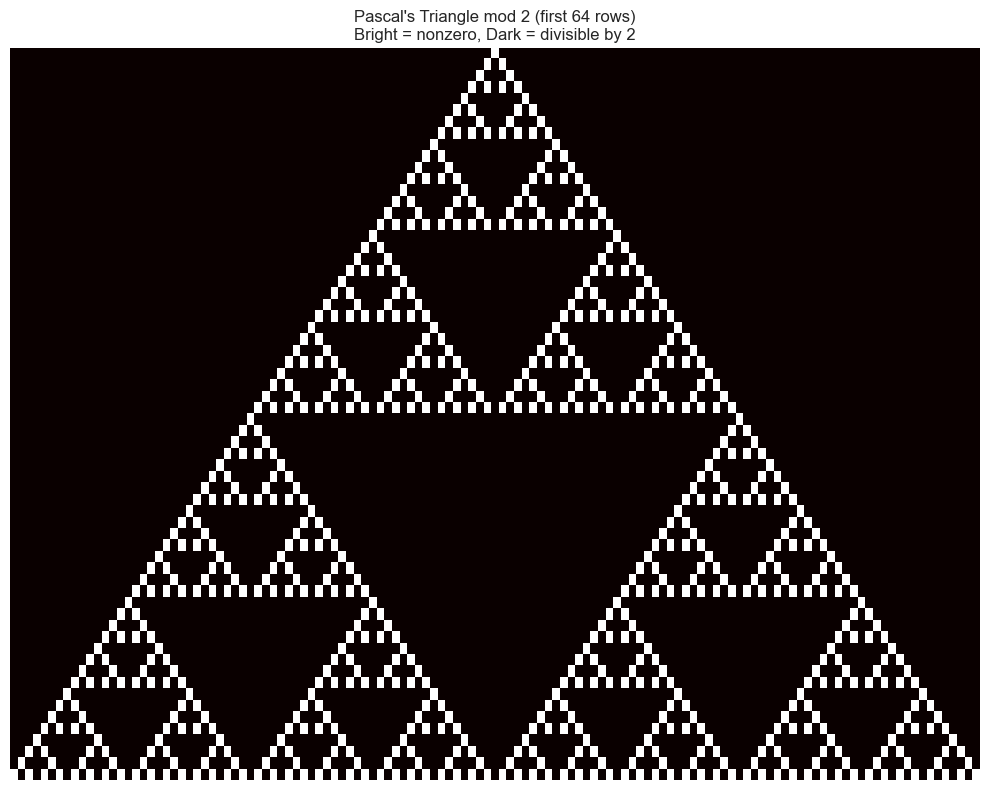

Entries divisible by 2:  1351
Total entries:  2080

With modulus=2: you see Sierpinski's triangle — a fractal.
With prime moduli: different fractals appear.
Conjecture: the pattern for prime p always produces a Sierpinski-like fractal.
This is true. It follows from Lucas' theorem (ch015 territory).


In [4]:
# --- Experiment: Pascal's triangle and hidden patterns ---
# Hypothesis: Pascal's triangle contains many non-obvious patterns.
# Try changing: N_ROWS and the modulus in the coloring

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

N_ROWS = 64     # <-- try: 32, 128
MODULUS = 2     # <-- try: 3, 5, 7 — watch different fractal patterns appear

def pascal_triangle(n):
    """Compute first n rows of Pascal's triangle."""
    triangle = []
    row = [1]
    for _ in range(n):
        triangle.append(row[:])
        row = [1] + [row[i] + row[i+1] for i in range(len(row)-1)] + [1]
    return triangle

rows = pascal_triangle(N_ROWS)

# Build a grid image: color by value mod MODULUS
grid = np.zeros((N_ROWS, 2 * N_ROWS - 1))
for i, row in enumerate(rows):
    start = N_ROWS - 1 - i
    for j, val in enumerate(row):
        grid[i, start + 2*j] = val % MODULUS

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(grid, cmap='hot', interpolation='nearest', aspect='auto')
ax.set_title(f"Pascal's Triangle mod {MODULUS} (first {N_ROWS} rows)\n"
             f"Bright = nonzero, Dark = divisible by {MODULUS}")
ax.axis('off')
plt.tight_layout()
plt.show()

# Count patterns
print(f"Entries divisible by {MODULUS}: ", sum(1 for row in rows for v in row if v % MODULUS == 0))
print(f"Total entries: ", sum(len(row) for row in rows))
print()
print("With modulus=2: you see Sierpinski's triangle — a fractal.")
print("With prime moduli: different fractals appear.")
print("Conjecture: the pattern for prime p always produces a Sierpinski-like fractal.")
print("This is true. It follows from Lucas' theorem (ch015 territory).")

## 7. Exercises

**Easy 1.** The Collatz function is defined for positive integers. What happens if you apply it to negative integers? Modify `collatz_sequence` to handle negatives and explore whether sequences still eventually cycle. *(Expected: observed cycle for negative inputs)*

**Easy 2.** Use `test_conjecture` to test: "For any integer n, n³ - n is divisible by 6." Test it on 5000 random integers in [-500, 500]. *(Expected: consistent, zero counterexamples)*

**Medium 1.** Explore the sequence defined by: start with any positive integer, repeatedly apply: if divisible by 3, divide by 3; else multiply by 3 and subtract 1. Does every starting point eventually cycle? Use `collatz_length` as a template, run it for starting values 1–200, plot the number of steps, and state a precise conjecture about what you observe.

**Medium 2.** Pascal's triangle mod 2 produces Sierpinski's triangle. Prove computationally that row n of Pascal's triangle contains all odd entries if and only if n+1 is a power of 2. Test for the first 128 rows.

**Hard.** The sum-of-cubes identity says $\sum_{k=1}^n k^3 = \left(\sum_{k=1}^n k\right)^2$. This is remarkable: the cube sum equals the square of the ordinary sum. Explore whether an analogous identity holds for higher powers: does $\sum k^p$ equal some simple expression involving $\sum k^q$ for $q < p$? Test for $p = 4, 5$ numerically and determine what polynomial in $n$ fits the sum. *(Challenge: use `np.polyfit` on the sequence and identify the degree)*

## 8. Mini Project

**Prime Gap Explorer**

The gaps between consecutive primes (2,3,5,7,11,...) have been studied for centuries. Many patterns are known; others remain conjectural. Explore the distribution of prime gaps computationally and formulate three precise conjectures of your own.

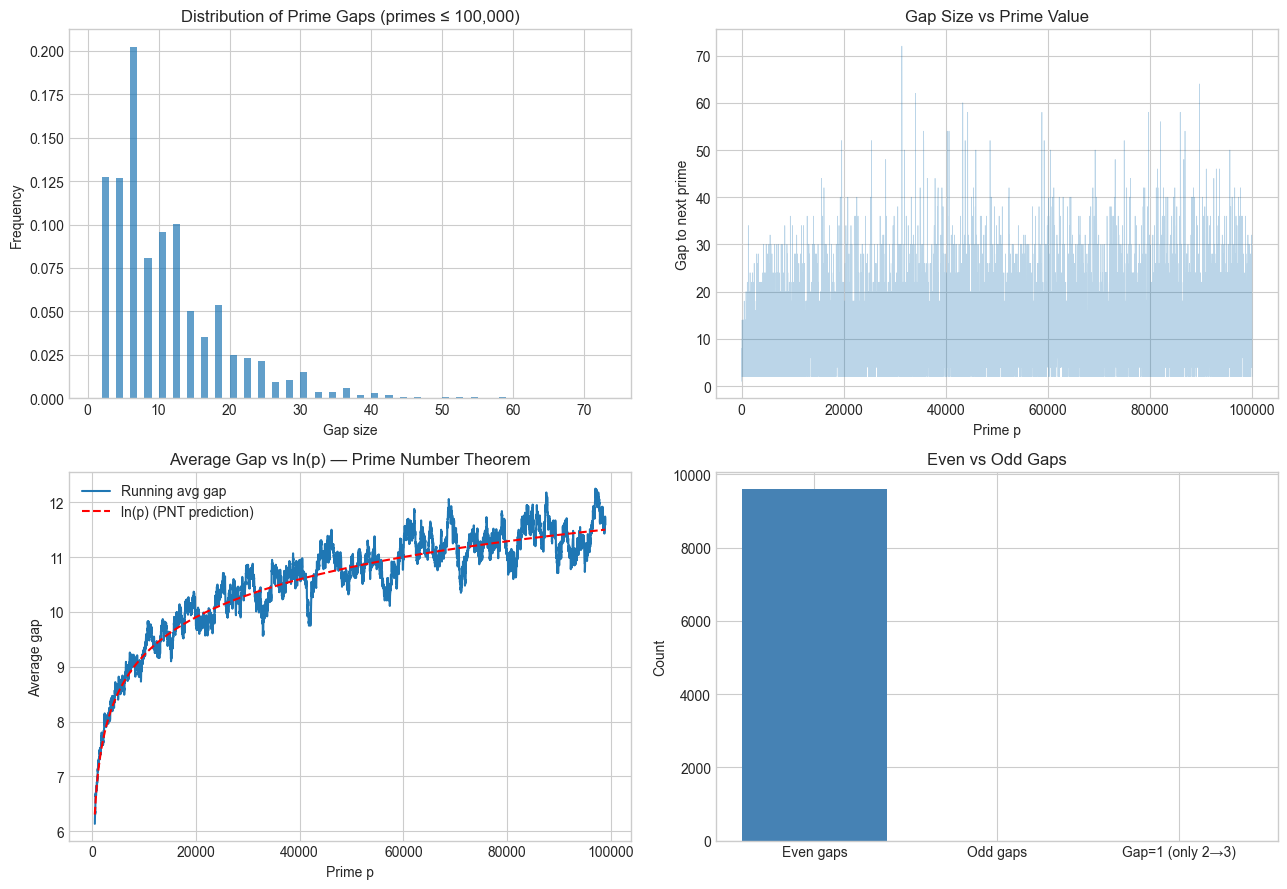

Twin primes (gap=2) up to 100000: 1224 pairs
Largest gap found: 72 (after prime 31397)
All gaps except first are even: True

TODO: Formulate 3 conjectures of your own based on these plots.
Example format: 'For all primes p > 2, the gap after p is...'


In [5]:
# --- Mini Project: Prime Gap Explorer ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def sieve_of_eratosthenes(limit):
    """Return all primes up to limit using the Sieve of Eratosthenes."""
    is_p = np.ones(limit + 1, dtype=bool)
    is_p[0] = is_p[1] = False
    for i in range(2, int(limit**0.5) + 1):
        if is_p[i]:
            is_p[i*i::i] = False
    return np.where(is_p)[0]

LIMIT = 100_000
primes = sieve_of_eratosthenes(LIMIT)
gaps = np.diff(primes)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].hist(gaps, bins=range(1, gaps.max()+2), density=True, alpha=0.7)
axes[0,0].set_xlabel('Gap size'); axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of Prime Gaps (primes ≤ 100,000)')

axes[0,1].plot(primes[:-1], gaps, alpha=0.3, linewidth=0.5)
axes[0,1].set_xlabel('Prime p'); axes[0,1].set_ylabel('Gap to next prime')
axes[0,1].set_title('Gap Size vs Prime Value')

# Running average gap vs log(p) — prime number theorem predicts gap ≈ ln(p)
window = 200
running_avg = np.convolve(gaps, np.ones(window)/window, mode='valid')
p_mid = primes[window//2 : window//2 + len(running_avg)]
axes[1,0].plot(p_mid, running_avg, label='Running avg gap', linewidth=1.5)
axes[1,0].plot(p_mid, np.log(p_mid), 'r--', label='ln(p) (PNT prediction)', linewidth=1.5)
axes[1,0].set_xlabel('Prime p'); axes[1,0].set_ylabel('Average gap')
axes[1,0].set_title('Average Gap vs ln(p) — Prime Number Theorem')
axes[1,0].legend()

# Even gaps dominate (twin prime territory)
even_gaps = gaps[gaps % 2 == 0]
odd_gaps  = gaps[gaps % 2 != 0]
axes[1,1].bar(['Even gaps', 'Odd gaps', 'Gap=1 (only 2→3)'],
              [len(even_gaps), len(odd_gaps), 1],
              color=['steelblue', 'coral', 'green'])
axes[1,1].set_ylabel('Count'); axes[1,1].set_title('Even vs Odd Gaps')

plt.tight_layout()
plt.show()

twin_primes = primes[:-1][gaps == 2]
print(f"Twin primes (gap=2) up to {LIMIT}: {len(twin_primes)} pairs")
print(f"Largest gap found: {gaps.max()} (after prime {primes[:-1][np.argmax(gaps)]})") 
print(f"All gaps except first are even: {np.all(gaps[1:] % 2 == 0)}")
print()
print("TODO: Formulate 3 conjectures of your own based on these plots.")
print("Example format: 'For all primes p > 2, the gap after p is...'")

## 9. Chapter Summary & Connections

- Mathematical discovery follows an exploration loop: observe → conjecture → test → refine — proof comes last, not first
- A conjecture must be precisely stated as a universal claim with a defined domain; imprecise pattern observations are not conjectures
- Computational testing is asymmetric: one counterexample definitively refutes; passing all tests only provides evidence
- Exploration is a legitimate mathematical method — Gauss, Euler, and Ramanujan all worked this way

**Forward:** The conjecture-testing infrastructure built here reappears in ch015 — Mathematical Proof Intuition, where we turn computationally consistent conjectures into formal arguments. The prime gap patterns connect to ch045 — Exponential Growth, where the Prime Number Theorem (average gap ≈ ln(p)) is revisited as a statement about growth rates.

**Backward:** This chapter extends ch002's property-based testing *(ch002 — Mathematics vs Programming Thinking)*: we are now using random testing not to verify software but to probe mathematical truth.